Load Data

In [ ]:
# load data
import pandas as pd
test_Data = pd.read_csv("testset.csv")
train_Data = pd.read_csv("trainset.csv")

In [ ]:
# get data types
train_Data.dtypes

,0
age,int64
job,object
marital,object
education,object
housing,object
loan,object
contact,object
month,object
day_of_week,object
duration,int64


In [ ]:
# Display train Data
train_Data

,age,job,marital,education,housing,loan,contact,month,day_of_week,duration,campaign,pdays,poutcome,nr.employed,Subscribed
0,41,blue-collar,divorced,basic.4y,yes,no,telephone,may,mon,1575,1,999,nonexistent,5191.0,yes
1,49,entrepreneur,married,university.degree,yes,no,telephone,may,mon,1042,1,999,nonexistent,5191.0,yes
2,49,technician,married,basic.9y,no,no,telephone,may,mon,1467,1,999,nonexistent,5191.0,yes
3,41,technician,married,professional.course,yes,no,telephone,may,mon,579,1,999,nonexistent,5191.0,yes
4,45,blue-collar,married,basic.9y,yes,no,telephone,may,mon,461,1,999,nonexistent,5191.0,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29266,49,admin.,married,unknown,no,no,cellular,nov,fri,288,1,999,failure,5195.8,no
29267,34,management,single,university.degree,unknown,unknown,telephone,nov,fri,114,5,999,nonexistent,5195.8,no
29268,29,technician,single,professional.course,no,no,cellular,nov,fri,161,3,999,nonexistent,5195.8,no
29269,57,blue-collar,married,basic.9y,no,yes,cellular,nov,fri,150,2,999,nonexistent,5195.8,no


Map the Subscribed value

In [ ]:
train_Data['Subscribed_val'] = train_Data['Subscribed']
train_Data['Subscribed_val'] = train_Data['Subscribed_val'].map({'yes': 1, 'no': 0})
train_Data

,age,job,marital,education,housing,loan,contact,month,day_of_week,duration,campaign,pdays,poutcome,nr.employed,Subscribed,Subscribed_val
0,41,blue-collar,divorced,basic.4y,yes,no,telephone,may,mon,1575,1,999,nonexistent,5191.0,yes,1
1,49,entrepreneur,married,university.degree,yes,no,telephone,may,mon,1042,1,999,nonexistent,5191.0,yes,1
2,49,technician,married,basic.9y,no,no,telephone,may,mon,1467,1,999,nonexistent,5191.0,yes,1
3,41,technician,married,professional.course,yes,no,telephone,may,mon,579,1,999,nonexistent,5191.0,yes,1
4,45,blue-collar,married,basic.9y,yes,no,telephone,may,mon,461,1,999,nonexistent,5191.0,yes,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29266,49,admin.,married,unknown,no,no,cellular,nov,fri,288,1,999,failure,5195.8,no,0
29267,34,management,single,university.degree,unknown,unknown,telephone,nov,fri,114,5,999,nonexistent,5195.8,no,0
29268,29,technician,single,professional.course,no,no,cellular,nov,fri,161,3,999,nonexistent,5195.8,no,0
29269,57,blue-collar,married,basic.9y,no,yes,cellular,nov,fri,150,2,999,nonexistent,5195.8,no,0


Data exploration & cleaning

Split the dataset for local estimator impute

In [ ]:
# Define 'unknown' as null
train_Data.replace('unknown', None, inplace=True)

# Split the dataset into two based on 'Subscribed'
train_Data_yes = train_Data[train_Data['Subscribed'] == 'yes'].copy()  # Subset where subscribed = 'yes'
train_Data_no = train_Data[train_Data['Subscribed'] == 'no'].copy()
train_Data_yes

,age,job,marital,education,housing,loan,contact,month,day_of_week,duration,campaign,pdays,poutcome,nr.employed,Subscribed,Subscribed_val
0,41,blue-collar,divorced,basic.4y,yes,no,telephone,may,mon,1575,1,999,nonexistent,5191.0,yes,1
1,49,entrepreneur,married,university.degree,yes,no,telephone,may,mon,1042,1,999,nonexistent,5191.0,yes,1
2,49,technician,married,basic.9y,no,no,telephone,may,mon,1467,1,999,nonexistent,5191.0,yes,1
3,41,technician,married,professional.course,yes,no,telephone,may,mon,579,1,999,nonexistent,5191.0,yes,1
4,45,blue-collar,married,basic.9y,yes,no,telephone,may,mon,461,1,999,nonexistent,5191.0,yes,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3191,49,admin.,single,high.school,yes,no,telephone,oct,fri,434,1,999,failure,5017.5,yes,1
3192,50,technician,married,professional.course,None,None,cellular,oct,fri,447,1,8,failure,5017.5,yes,1
3193,33,admin.,married,university.degree,no,no,cellular,oct,fri,130,1,6,success,5017.5,yes,1
3194,38,technician,married,university.degree,no,no,cellular,oct,fri,156,1,999,nonexistent,5017.5,yes,1


In [ ]:
# local estimator impute 'unknown' values
for column in train_Data_yes.columns:
    if train_Data_yes[column].isnull().any():  # Check if the column contains null values
        mode_value = train_Data_yes[column].mode()[0]  # Find the mode of the column
        train_Data_yes.fillna({column: mode_value}, inplace=True)  # Fill nulls with the mode

# Display the updated Dataset
train_Data_yes


,age,job,marital,education,housing,loan,contact,month,day_of_week,duration,campaign,pdays,poutcome,nr.employed,Subscribed,Subscribed_val
0,41,blue-collar,divorced,basic.4y,yes,no,telephone,may,mon,1575,1,999,nonexistent,5191.0,yes,1
1,49,entrepreneur,married,university.degree,yes,no,telephone,may,mon,1042,1,999,nonexistent,5191.0,yes,1
2,49,technician,married,basic.9y,no,no,telephone,may,mon,1467,1,999,nonexistent,5191.0,yes,1
3,41,technician,married,professional.course,yes,no,telephone,may,mon,579,1,999,nonexistent,5191.0,yes,1
4,45,blue-collar,married,basic.9y,yes,no,telephone,may,mon,461,1,999,nonexistent,5191.0,yes,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3191,49,admin.,single,high.school,yes,no,telephone,oct,fri,434,1,999,failure,5017.5,yes,1
3192,50,technician,married,professional.course,yes,no,cellular,oct,fri,447,1,8,failure,5017.5,yes,1
3193,33,admin.,married,university.degree,no,no,cellular,oct,fri,130,1,6,success,5017.5,yes,1
3194,38,technician,married,university.degree,no,no,cellular,oct,fri,156,1,999,nonexistent,5017.5,yes,1


In [ ]:
# local estimator impute 'unknown' values
for column in train_Data_no.columns:
    if train_Data_no[column].isnull().any():  # Check if the column contains null values
        mode_value = train_Data_no[column].mode()[0]  # Find the mode of the column
        train_Data_no.fillna({column: mode_value}, inplace=True)  # Fill nulls with the mode

# Display the updated Dataset
train_Data_no

,age,job,marital,education,housing,loan,contact,month,day_of_week,duration,campaign,pdays,poutcome,nr.employed,Subscribed,Subscribed_val
3196,56,housemaid,married,basic.4y,no,no,telephone,may,mon,261,1,999,nonexistent,5191.0,no,0
3197,57,services,married,high.school,no,no,telephone,may,mon,149,1,999,nonexistent,5191.0,no,0
3198,37,services,married,high.school,yes,no,telephone,may,mon,226,1,999,nonexistent,5191.0,no,0
3199,40,admin.,married,basic.6y,no,no,telephone,may,mon,151,1,999,nonexistent,5191.0,no,0
3200,56,services,married,high.school,no,yes,telephone,may,mon,307,1,999,nonexistent,5191.0,no,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29266,49,admin.,married,university.degree,no,no,cellular,nov,fri,288,1,999,failure,5195.8,no,0
29267,34,management,single,university.degree,yes,no,telephone,nov,fri,114,5,999,nonexistent,5195.8,no,0
29268,29,technician,single,professional.course,no,no,cellular,nov,fri,161,3,999,nonexistent,5195.8,no,0
29269,57,blue-collar,married,basic.9y,no,yes,cellular,nov,fri,150,2,999,nonexistent,5195.8,no,0


In [ ]:
# merge the 2 dataset back
train_Data_cleaned = pd.concat([train_Data_yes, train_Data_no], axis=0).reset_index(drop=True)

# check for null
train_Data_cleaned.isnull().sum()

,0
age,0
job,0
marital,0
education,0
housing,0
loan,0
contact,0
month,0
day_of_week,0
duration,0


Display the distribution of all attributes for data exploration

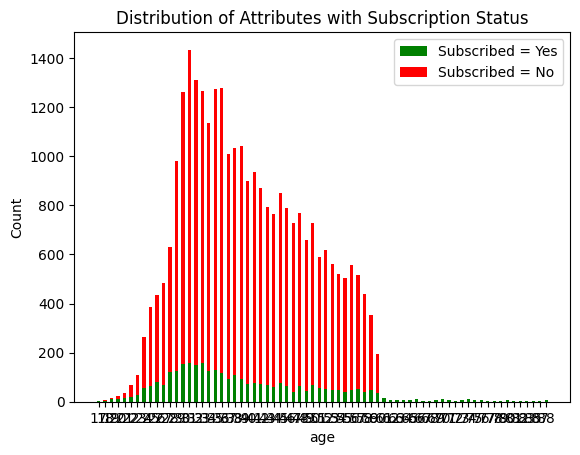

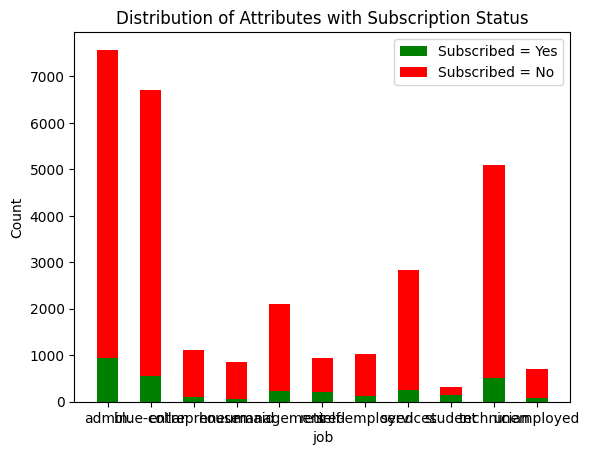

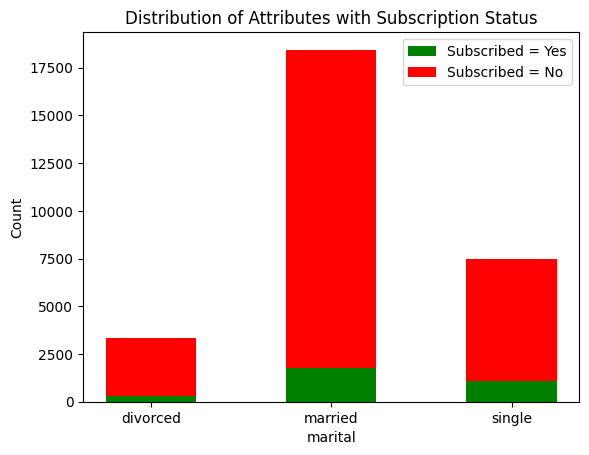

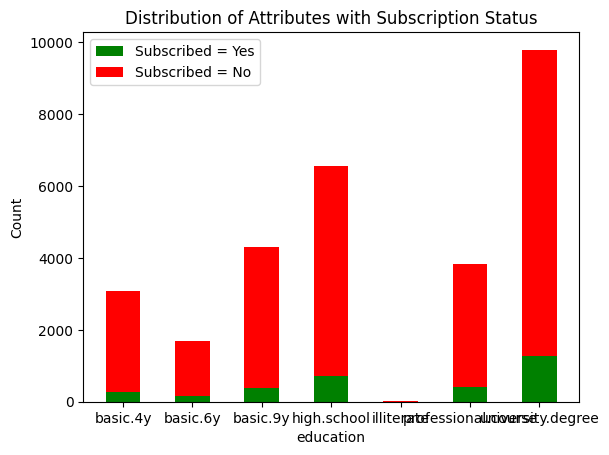

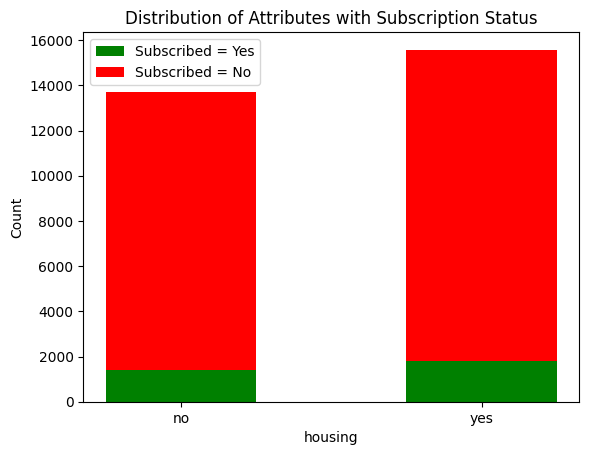

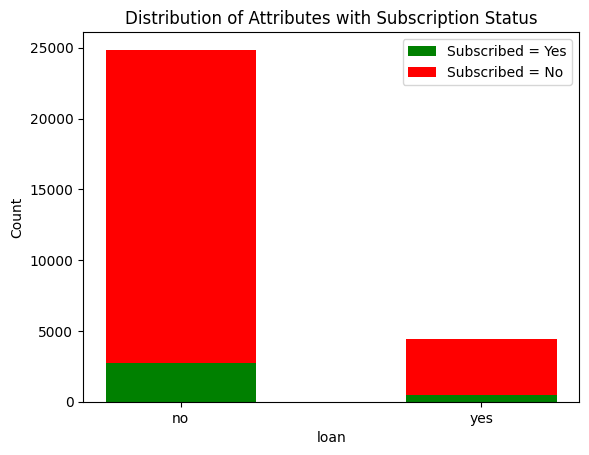

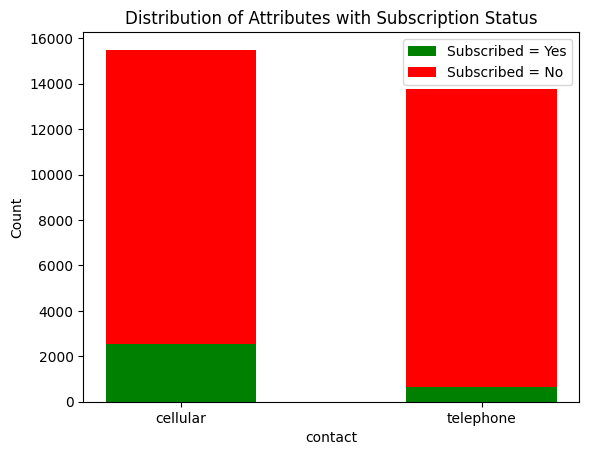

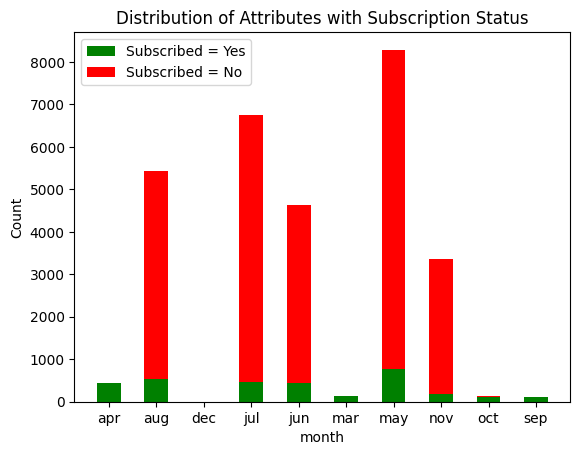

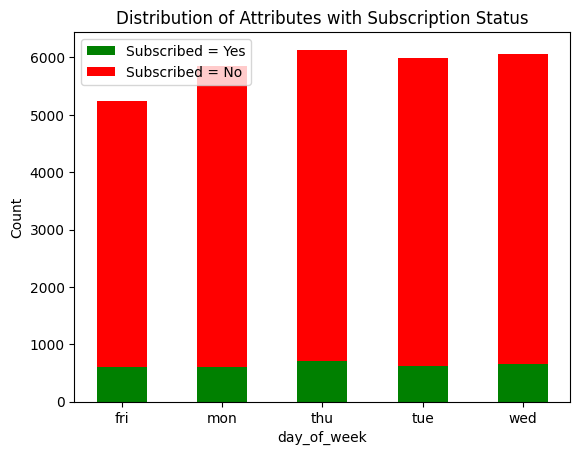

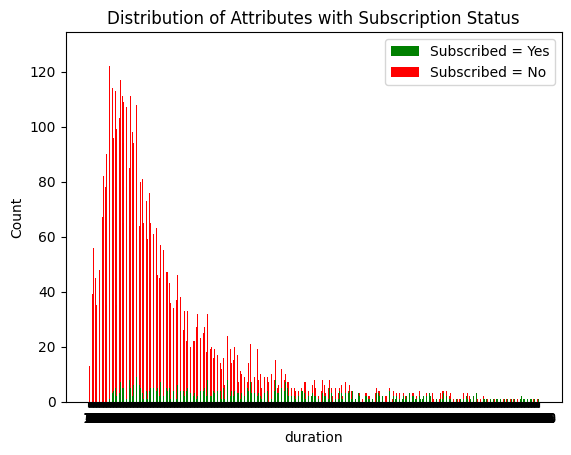

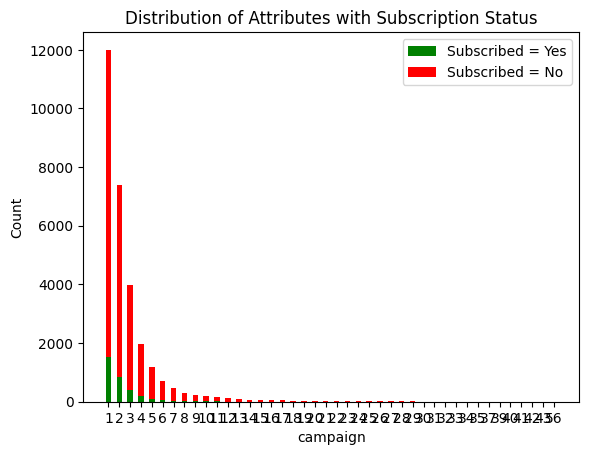

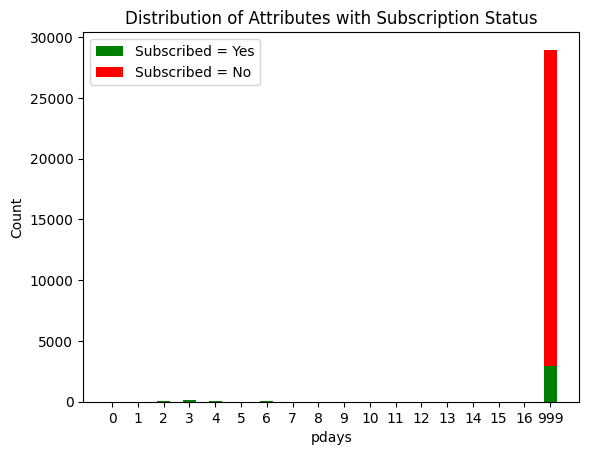

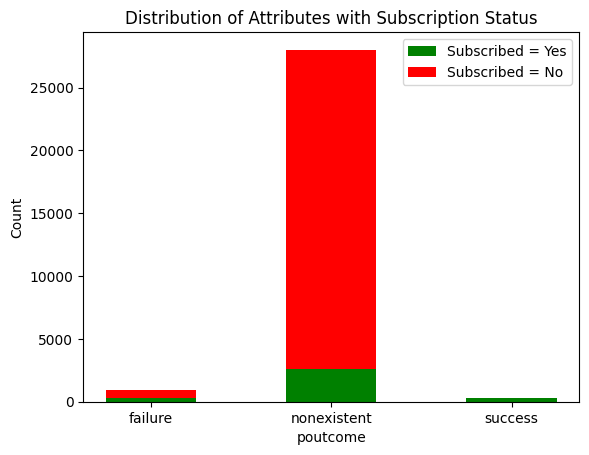

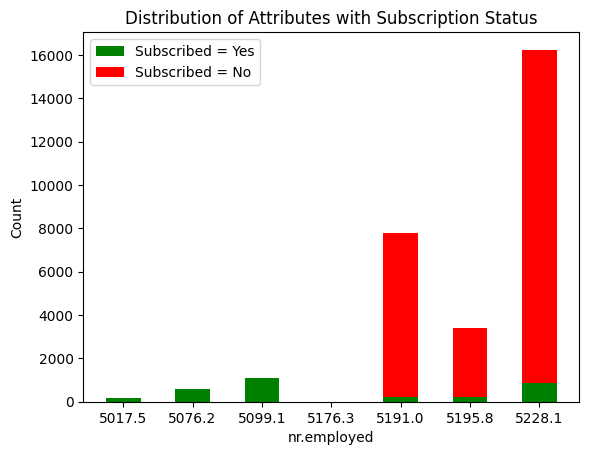

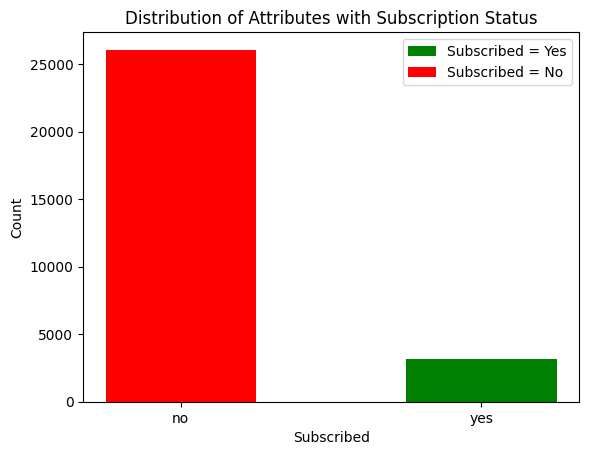

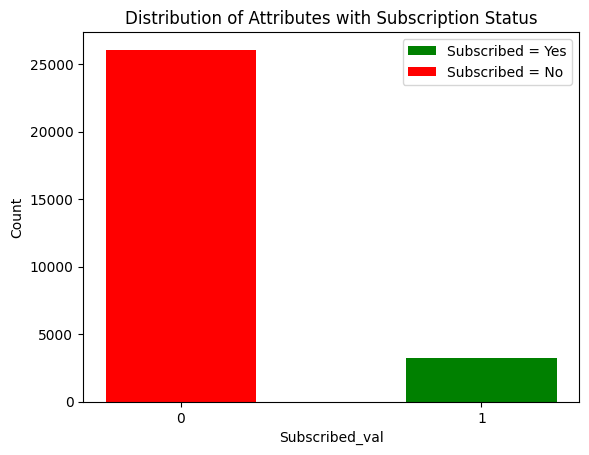

In [ ]:
import matplotlib.pyplot as plt
for column in train_Data_cleaned.columns:
  grouped_data = train_Data_cleaned.groupby([column, 'Subscribed']).size().unstack(fill_value=0)

# Prepare the data for the stacked bar chart
  marital_status = grouped_data.index
  subscribed_yes = grouped_data['yes']
  subscribed_no = grouped_data['no']

# Plot the stacked bar chart
  bar_width = 0.5  # Width of the bars
  x = range(len(marital_status))  # Positions for bars

  plt.bar(x, subscribed_yes, color='green', label='Subscribed = Yes', width=bar_width)
  plt.bar(x, subscribed_no, color='red', label='Subscribed = No', bottom=subscribed_yes, width=bar_width)

# Add labels, title, and legend
  plt.xlabel(column)
  plt.ylabel('Count')
  plt.title('Distribution of Attributes with Subscription Status')
  plt.xticks(x, marital_status)  # Set x-axis labels
  plt.legend()

# Show the plot
  plt.show()

Encode attribute values

In [ ]:
print('unique values of attribute job:', train_Data_cleaned.job.unique())
train_Data_cleaned = pd.get_dummies(train_Data_cleaned, columns=['job'], dtype=int)

unique values of attribute job: ['blue-collar' 'entrepreneur' 'technician' 'housemaid' 'admin.' 'services'
 'management' 'student' 'unemployed' 'self-employed' 'retired']


In [ ]:
print('unique values of attribute marital:', train_Data_cleaned.marital.unique())
train_Data_cleaned = pd.get_dummies(train_Data_cleaned, columns=['marital'], dtype=int)

unique values of attribute marital: ['divorced' 'married' 'single']


In [ ]:
print('unique values of attribute education:', train_Data_cleaned.education.unique())
train_Data_cleaned = pd.get_dummies(train_Data_cleaned, columns=['education'], dtype=int)

unique values of attribute education: ['basic.4y' 'university.degree' 'basic.9y' 'professional.course'
 'high.school' 'basic.6y' 'illiterate']


In [ ]:
train_Data_cleaned['loan_val'] = train_Data_cleaned['loan']
train_Data_cleaned['loan_val'] = train_Data_cleaned['loan_val'].map({'yes': 1, 'no': 0})

In [ ]:
train_Data_cleaned['housing_val'] = train_Data_cleaned['housing']
train_Data_cleaned['housing_val'] = train_Data_cleaned['housing_val'].map({'yes': 1, 'no': 0})

In [ ]:
print('unique values of attribute contact:', train_Data_cleaned.contact.unique())
train_Data_cleaned = pd.get_dummies(train_Data_cleaned, columns=['contact'], dtype=int)

unique values of attribute contact: ['telephone' 'cellular']


In [ ]:
print('unique values of attribute month:', train_Data_cleaned.month.unique())
train_Data_cleaned = pd.get_dummies(train_Data_cleaned, columns=['month'], dtype=int)

unique values of attribute month: ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'mar' 'apr' 'sep']


In [ ]:
train_Data_cleaned.replace({'pdays': {999: -1}}, inplace=True)
print('unique values of attribute pdays:', train_Data_cleaned.pdays.unique())

unique values of attribute pdays: [-1  5  6 10  7 11  2  0  3  9 12  1  4 13 14 15 16  8]


In [ ]:
print('unique values of attribute day of week:', train_Data_cleaned.day_of_week.unique())
train_Data_cleaned = pd.get_dummies(train_Data_cleaned, columns=['day_of_week'], dtype=int)

unique values of attribute day of week: ['mon' 'tue' 'wed' 'thu' 'fri']


In [ ]:
print('unique values of attribute outcome:', train_Data_cleaned.poutcome.unique())
train_Data_cleaned = pd.get_dummies(train_Data_cleaned, columns=['poutcome'], dtype=int)

unique values of attribute outcome: ['nonexistent' 'failure' 'success']


In [ ]:
# label encode the 'nr.employed' attributes
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
train_Data_cleaned['nr.employed'] = le.fit_transform(train_Data_cleaned['nr.employed'])
print('unique values of attribute nr.employed:', train_Data_cleaned['nr.employed'].unique())

unique values of attribute nr.employed: [4 6 5 3 2 1 0]


In [ ]:
train_Data_cleaned

,age,housing,loan,duration,campaign,pdays,nr.employed,Subscribed,Subscribed_val,job_admin.,...,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
0,41,yes,no,1575,1,-1,4,yes,1,0,...,0,0,0,1,0,0,0,0,1,0
1,49,yes,no,1042,1,-1,4,yes,1,0,...,0,0,0,1,0,0,0,0,1,0
2,49,no,no,1467,1,-1,4,yes,1,0,...,0,0,0,1,0,0,0,0,1,0
3,41,yes,no,579,1,-1,4,yes,1,0,...,0,0,0,1,0,0,0,0,1,0
4,45,yes,no,461,1,-1,4,yes,1,0,...,0,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29266,49,no,no,288,1,-1,5,no,0,1,...,0,0,1,0,0,0,0,1,0,0
29267,34,yes,no,114,5,-1,5,no,0,0,...,0,0,1,0,0,0,0,0,1,0
29268,29,no,no,161,3,-1,5,no,0,0,...,0,0,1,0,0,0,0,0,1,0
29269,57,no,yes,150,2,-1,5,no,0,0,...,0,0,1,0,0,0,0,0,1,0


In [ ]:
# all attributes
print(train_Data_cleaned.columns)
len(train_Data_cleaned.columns)

Index(['age', 'housing', 'loan', 'duration', 'campaign', 'pdays',
       'nr.employed', 'Subscribed', 'Subscribed_val', 'job_admin.',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'marital_divorced',
       'marital_married', 'marital_single', 'education_basic.4y',
       'education_basic.6y', 'education_basic.9y', 'education_high.school',
       'education_illiterate', 'education_professional.course',
       'education_university.degree', 'loan_val', 'housing_val',
       'contact_cellular', 'contact_telephone', 'month_apr', 'month_aug',
       'month_dec', 'month_jul', 'month_jun', 'month_mar', 'month_may',
       'month_nov', 'month_oct', 'month_sep', 'day_of_week_fri',
       'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue',
       'day_of_week_wed', 'poutcome_failure', 'poutcome_nonexistent',
       'poutcome_success'],
    

52

In [ ]:
# Checking for null
train_Data_cleaned.isnull().sum()

,0
age,0
housing,0
loan,0
duration,0
campaign,0
pdays,0
nr.employed,0
Subscribed,0
Subscribed_val,0
job_admin.,0


Do the same for test data - cleaning & imputing

In [ ]:
# Define 'unknown' as null
test_Data.replace('unknown', None, inplace=True)

# Split the dataset into two based on 'Subscribed'
test_Data_yes = test_Data[test_Data['Subscribed'] == 'yes'].copy()  # Subset where subscribed = 'yes'
test_Data_no = test_Data[test_Data['Subscribed'] == 'no'].copy()

In [ ]:
# impute the dataset with local estimator
for column in test_Data_yes.columns:
    if test_Data_yes[column].isnull().any():  # Check if the column contains null values
        mode_value = test_Data_yes[column].mode()[0]  # Find the mode of the column
        test_Data_yes.fillna({column: mode_value}, inplace=True)  # Fill nulls with the mode

for column in test_Data_no.columns:
    if test_Data_no[column].isnull().any():  # Check if the column contains null values
        mode_value = test_Data_no[column].mode()[0]  # Find the mode of the column
        test_Data_no.fillna({column: mode_value}, inplace=True)  # Fill nulls with the mode

# display the data
test_Data_yes

,age,job,marital,education,housing,loan,contact,month,day_of_week,duration,campaign,pdays,poutcome,nr.employed,Subscribed
0,62,retired,married,university.degree,no,no,cellular,oct,fri,717,2,999,nonexistent,5017.5,yes
1,49,admin.,single,high.school,yes,no,cellular,oct,fri,136,2,999,nonexistent,5017.5,yes
2,36,admin.,married,university.degree,no,no,cellular,oct,fri,342,1,999,failure,5017.5,yes
3,70,retired,married,basic.4y,yes,no,cellular,oct,mon,131,1,999,nonexistent,5017.5,yes
4,60,retired,married,basic.4y,no,no,cellular,oct,mon,98,1,999,nonexistent,5017.5,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1439,62,retired,married,university.degree,yes,no,cellular,nov,thu,208,1,1,success,4963.6,yes
1440,62,retired,married,university.degree,no,no,cellular,nov,thu,483,2,6,success,4963.6,yes
1441,37,admin.,married,university.degree,yes,no,cellular,nov,fri,281,1,999,nonexistent,4963.6,yes
1442,73,retired,married,professional.course,yes,no,cellular,nov,fri,334,1,999,nonexistent,4963.6,yes


In [ ]:
# merge the dataset back
test_Data_cleaned = pd.concat([test_Data_yes, test_Data_no], axis=0).reset_index(drop=True)

# check for null
test_Data_cleaned.isnull().sum()

,0
age,0
job,0
marital,0
education,0
housing,0
loan,0
contact,0
month,0
day_of_week,0
duration,0


Encode the test data set

In [ ]:
test_Data_cleaned['Subscribed_val'] = test_Data_cleaned['Subscribed']
test_Data_cleaned['Subscribed_val'] = test_Data_cleaned['Subscribed_val'].map({'yes': 1, 'no': 0})

In [ ]:
test_Data_cleaned.replace({'pdays': {999: -1}}, inplace=True)
print('unique values of attribute pdays:', test_Data_cleaned.pdays.unique())

unique values of attribute pdays: [-1  6  7  8  3  2  4  5  9 13 10 21 11 12 14 18 15  1 22 16 25 26  0 17
 27 19 20]


In [ ]:
test_Data_cleaned['nr.employed'] = le.fit_transform(test_Data_cleaned['nr.employed'])
print('unique values of attribute nr.employed:', test_Data_cleaned['nr.employed'].unique())

unique values of attribute nr.employed: [3 4 2 1 0 8 7 6 5]


In [ ]:
print('unique values of attribute job:', test_Data_cleaned.job.unique())
test_Data_cleaned = pd.get_dummies(test_Data_cleaned, columns=['job'], dtype=int)

print('unique values of attribute marital:', test_Data_cleaned.marital.unique())
test_Data_cleaned = pd.get_dummies(test_Data_cleaned, columns=['marital'], dtype=int)

print('unique values of attribute education:', test_Data_cleaned.education.unique())
test_Data_cleaned = pd.get_dummies(test_Data_cleaned, columns=['education'], dtype=int)

test_Data_cleaned['loan_val'] = test_Data_cleaned['loan']
test_Data_cleaned['loan_val'] = test_Data_cleaned['loan_val'].map({'yes': 1, 'no': 0})

test_Data_cleaned['housing_val'] = test_Data_cleaned['housing']
test_Data_cleaned['housing_val'] = test_Data_cleaned['housing_val'].map({'yes': 1, 'no': 0})

print('unique values of attribute contact:', test_Data_cleaned.contact.unique())
test_Data_cleaned = pd.get_dummies(test_Data_cleaned, columns=['contact'], dtype=int)

print('unique values of attribute month:', test_Data_cleaned.month.unique())
test_Data_cleaned = pd.get_dummies(test_Data_cleaned, columns=['month'], dtype=int)

print('unique values of attribute day of week:', test_Data_cleaned.day_of_week.unique())
test_Data_cleaned = pd.get_dummies(test_Data_cleaned, columns=['day_of_week'], dtype=int)

print('unique values of attribute outcome:', test_Data_cleaned.poutcome.unique())
test_Data_cleaned = pd.get_dummies(test_Data_cleaned, columns=['poutcome'], dtype=int)

unique values of attribute job: ['retired' 'admin.' 'services' 'student' 'management' 'technician'
 'housemaid' 'blue-collar' 'unemployed' 'entrepreneur' 'self-employed']
unique values of attribute marital: ['married' 'single' 'divorced']
unique values of attribute education: ['university.degree' 'high.school' 'basic.4y' 'basic.6y'
 'professional.course' 'basic.9y' 'illiterate']
unique values of attribute contact: ['cellular' 'telephone']
unique values of attribute month: ['oct' 'nov' 'dec' 'mar' 'apr' 'may' 'jun' 'jul' 'aug' 'sep']
unique values of attribute day of week: ['fri' 'mon' 'tue' 'wed' 'thu']
unique values of attribute outcome: ['nonexistent' 'failure' 'success']


In [ ]:
test_Data_cleaned

,age,housing,loan,duration,campaign,pdays,nr.employed,Subscribed,Subscribed_val,job_admin.,...,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
0,62,no,no,717,2,-1,3,yes,1,0,...,1,0,1,0,0,0,0,0,1,0
1,49,yes,no,136,2,-1,3,yes,1,1,...,1,0,1,0,0,0,0,0,1,0
2,36,no,no,342,1,-1,3,yes,1,1,...,1,0,1,0,0,0,0,1,0,0
3,70,yes,no,131,1,-1,3,yes,1,0,...,1,0,0,1,0,0,0,0,1,0
4,60,no,no,98,1,-1,3,yes,1,0,...,1,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11912,36,no,no,254,2,-1,0,no,0,1,...,0,0,1,0,0,0,0,0,1,0
11913,29,yes,no,112,1,9,0,no,0,0,...,0,0,1,0,0,0,0,0,0,1
11914,46,no,no,383,1,-1,0,no,0,0,...,0,0,1,0,0,0,0,0,1,0
11915,56,yes,no,189,2,-1,0,no,0,0,...,0,0,1,0,0,0,0,0,1,0


assign test/train X/Y

In [ ]:
train_y = train_Data_cleaned['Subscribed_val']
test_y = test_Data_cleaned['Subscribed_val']

# eliminate
train_X = train_Data_cleaned[[ 'age',  'campaign', 'duration', 'nr.employed', 'pdays',
       'loan_val', 'housing_val',
       'job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed',
       'marital_divorced', 'marital_married', 'marital_single',
       'education_basic.4y', 'education_basic.6y', 'education_basic.9y', 'education_high.school',
       'education_illiterate', 'education_professional.course', 'education_university.degree',
       'contact_cellular', 'contact_telephone',
       'month_apr', 'month_aug', 'month_dec', 'month_jul', 'month_jun',
       'month_nov', 'month_oct', 'month_sep', 'month_mar', 'month_may',
       'day_of_week_fri', 'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue','day_of_week_wed',
       'poutcome_failure', 'poutcome_nonexistent','poutcome_success'
       ]]

test_X = test_Data_cleaned[[ 'age', 'campaign', 'duration', 'nr.employed', 'pdays',
       'loan_val', 'housing_val',
       'job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed',
       'marital_divorced', 'marital_married', 'marital_single',
       'education_basic.4y', 'education_basic.6y', 'education_basic.9y', 'education_high.school',
       'education_illiterate', 'education_professional.course', 'education_university.degree',
       'contact_cellular', 'contact_telephone',
       'month_apr', 'month_aug', 'month_dec', 'month_jul', 'month_jun',
       'month_nov', 'month_oct', 'month_sep', 'month_mar', 'month_may',
       'day_of_week_fri', 'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue','day_of_week_wed',
       'poutcome_failure', 'poutcome_nonexistent','poutcome_success'
       ]]

# See the length of each data set
print('length of train:', len(train_X))
print('length of test:', len(test_X))

length of train: 29271
length of test: 11917


In [ ]:
test_X

,age,campaign,duration,nr.employed,pdays,loan_val,housing_val,job_admin.,job_blue-collar,job_entrepreneur,...,month_mar,month_may,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
0,62,2,717,3,-1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
1,49,2,136,3,-1,0,1,1,0,0,...,0,0,1,0,0,0,0,0,1,0
2,36,1,342,3,-1,0,0,1,0,0,...,0,0,1,0,0,0,0,1,0,0
3,70,1,131,3,-1,0,1,0,0,0,...,0,0,0,1,0,0,0,0,1,0
4,60,1,98,3,-1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11912,36,2,254,0,-1,0,0,1,0,0,...,0,0,1,0,0,0,0,0,1,0
11913,29,1,112,0,9,0,1,0,0,0,...,0,0,1,0,0,0,0,0,0,1
11914,46,1,383,0,-1,0,0,0,1,0,...,0,0,1,0,0,0,0,0,1,0
11915,56,2,189,0,-1,0,1,0,0,0,...,0,0,1,0,0,0,0,0,1,0


In [ ]:
# import decision tree from scikit learn
from sklearn import tree
tree1 = tree.DecisionTreeClassifier()
tree1.fit(train_X, train_y)

DecisionTreeClassifier()

In [ ]:
# get accuracy score
predictions = tree1.predict(test_X)

from sklearn.metrics import accuracy_score
print(accuracy_score(test_y, predictions))

0.8353612486364018


Visualize the tree

[Text(0.5159520385135609, 0.9821428571428571, 'x[3] <= 3.5\ngini = 0.195\nsamples = 29271\nvalue = [26075, 3196]'),
 Text(0.514982459068645, 0.9464285714285714, 'gini = 0.0\nsamples = 1858\nvalue = [0, 1858]'),
 Text(0.515467248791103, 0.9642857142857142, 'True  '),
 Text(0.5169216179584766, 0.9464285714285714, 'x[2] <= 614.5\ngini = 0.093\nsamples = 27413\nvalue = [26075, 1338]'),
 Text(0.5164368282360188, 0.9642857142857142, '  False'),
 Text(0.26461080001666465, 0.9107142857142857, 'x[2] <= 451.5\ngini = 0.029\nsamples = 25240\nvalue = [24869, 371]'),
 Text(0.145206830990183, 0.875, 'x[36] <= 0.5\ngini = 0.011\nsamples = 23589\nvalue = [23458, 131]'),
 Text(0.09940651133195977, 0.8392857142857143, 'x[2] <= 360.5\ngini = 0.008\nsamples = 23532\nvalue = [23436, 96]'),
 Text(0.04623681977942068, 0.8035714285714286, 'x[35] <= 0.5\ngini = 0.004\nsamples = 21927\nvalue = [21884.0, 43.0]'),
 Text(0.019846079263119622, 0.7678571428571429, 'x[2] <= 277.5\ngini = 0.002\nsamples = 19203\nvalue

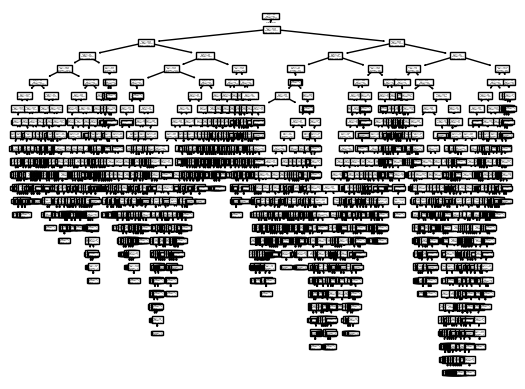

In [ ]:
tree.plot_tree(tree1)

In [ ]:
# export the tree to assignment.pdf
import graphviz
dot_data = tree.export_graphviz(tree1, out_file=None)
graph = graphviz.Source(dot_data)
graph.render("assignment")

'assignment.pdf'

Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

lm = LogisticRegression()

# build a logstic regression model using 41 attributes
lm.fit(train_X,train_y)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
# get parameters of regression

# use attributes to build the model, hence we have 36 weights
print("weights of the model are:", lm.coef_)
print("intercept of the model is:", lm.intercept_)
sort_no = lm.coef_[0]
print(sort_no.sort)

weights of the model are: [[ 0.0272009  -0.01426112  0.00539374 -1.77249479  0.41107568 -0.01371566
   0.02610934  0.12644478  0.3732844   0.0213431  -0.1098734   0.04320551
   0.09595864 -0.05177585  0.14234799  0.34739052  0.16143212  0.03547246
  -0.04472706  0.45273971  0.77721761 -0.2041971   0.06722963  0.25198911
   0.47000115  0.00723316  0.25336774  0.33960657  1.53495939 -0.34972912
   1.10203413  0.45245592  0.01581733  0.3166029   1.82917901 -1.68383325
   0.67603715  0.06523509  0.5347026  -2.12300063  0.47626526  0.30682881
  -0.01829433  0.05671659  0.36371394  0.17978136  0.75273785  0.25271105]]
intercept of the model is: [1.18963639]
<built-in method sort of numpy.ndarray object at 0x7dd898889590>


In [ ]:
# predic method predicts the class for the input dataset
# test the performance on test dataset
predicted_classes = lm.predict(test_X)

In [ ]:
# this is the actual classes that we extract from the test dataset
real_classes = test_y.values

In [ ]:
# calculate accuracy
accuracy = sum(real_classes == predicted_classes) / len(real_classes)
print("the accuracy of this model is:", accuracy)
print('number of (1) in real_classes is:', sum(real_classes))
print('number of (0) in real_classes is:', (len(real_classes) - sum(real_classes)))

the accuracy of this model is: 0.8567592514894689
number of (1) in real_classes is: 1444
number of (0) in real_classes is: 10473


Confusion Matrix

In [ ]:
# import confusion matrix
from sklearn.metrics import confusion_matrix
confusion_matrix(predicted_classes, real_classes, labels=[1,0])
TP, FP, FN, TN = confusion_matrix(predicted_classes, real_classes, labels=[1,0]).ravel()
print("TP: ",TP, "FP: ", FP, "FN: ",FN, "TN: ",TN)

# calculate precision
print('the precision of this model is:', (TP / (TP+FP)))
# calculate recall
print('the recall of this model is:', (TP / (TP+FN)))

TP:  1346 FP:  1609 FN:  98 TN:  8864
the precision of this model is: 0.45549915397631136
the recall of this model is: 0.9321329639889196


ROC Curve

In [ ]:
# ROC curve
from sklearn.metrics import roc_curve, roc_auc_score

# Returns the probability of the sample for each class in the model
y_scores = lm.predict_proba(test_X)

# show first five precited calsses
print(predicted_classes[:5])

# show first five scores (probabilities)
print(y_scores[:5])

[1 1 1 1 1]
[[0.00489503 0.99510497]
 [0.08796658 0.91203342]
 [0.11339301 0.88660699]
 [0.15464399 0.84535601]
 [0.22749322 0.77250678]]


In [ ]:
# get the scores of predicting (1)
prob_for_predicting_one = y_scores[:,1]
# show first five probabilities of being a (1)
prob_for_predicting_one[:5]

array([0.99510497, 0.91203342, 0.88660699, 0.84535601, 0.77250678])

In [ ]:
# prob_for_predicting_one in ROC metric's input is the probability estimation of the positive class
fpr, tpr, thresholds = roc_curve(real_classes, prob_for_predicting_one)
auc = roc_auc_score(real_classes, prob_for_predicting_one)

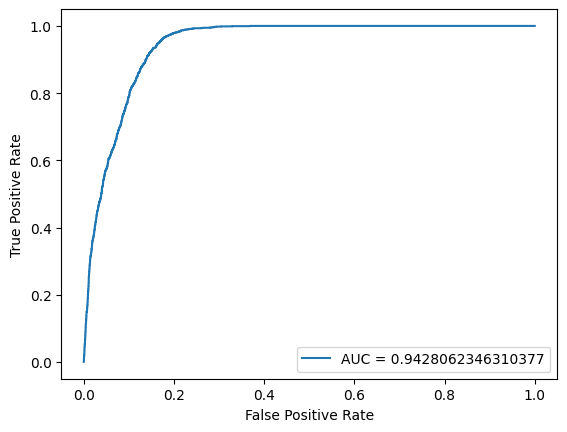

In [ ]:
# Visualize the ROC curve
import matplotlib.pyplot as plt

plt.plot(fpr, tpr, label='AUC = '+str(auc))
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend()
plt.show()

KNN

In [ ]:
# KNN
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(train_X, train_y)

KNeighborsClassifier()

In [ ]:
y_predicted_knn = knn.predict(test_X)

In [ ]:
# get accuracy
accuracy = sum(real_classes == y_predicted_knn) / len(real_classes)
print("the accuracy of this model is:", accuracy)

the accuracy of this model is: 0.8716958966182764


In [ ]:
# Get confusion matrix for knn
confusion_matrix(y_predicted_knn, real_classes, labels=[1,0])
TP, FP, FN, TN = confusion_matrix(y_predicted_knn, real_classes, labels=[1,0]).ravel()
print("TP: ",TP, "FP: ", FP, "FN: ",FN, "TN: ",TN)

# calculate precision
print('the precision of this model is:', (TP / (TP+FP)))
# calculate recall
print('the recall of this model is:', (TP / (TP+FN)))

TP:  823 FP:  908 FN:  621 TN:  9565
the precision of this model is: 0.4754477180820335
the recall of this model is: 0.5699445983379502


In [ ]:
y_scores_knn = knn.predict_proba(test_X)

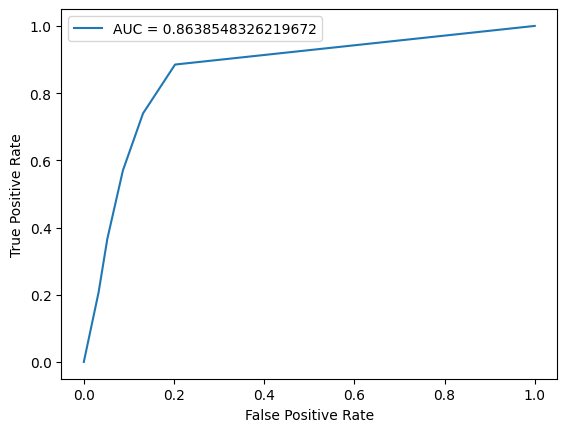

In [ ]:
# get the scores of predicting (1)
prob_for_predicting_one = y_scores_knn[:,1]

# prob_for_predicting_one in ROC metric's input is the probability estimation of the positive class
fpr, tpr, thresholds = roc_curve(real_classes, prob_for_predicting_one)
auc = roc_auc_score(real_classes, prob_for_predicting_one)

# Visualize ROC curve
plt.plot(fpr, tpr, label='AUC = '+str(auc))
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend()
plt.show()

Assemble the 3 model

In [ ]:
# import Stacking model
from sklearn.ensemble import StackingClassifier

# Assemble the 3 models
stack_clf = StackingClassifier(estimators=[
    ('DecisionTree', tree1),
    ('LogisticRegression', lm),
    ('KNN', knn)
], final_estimator=LogisticRegression())

# Get accuracy score
stack_clf.fit(train_X, train_y)
y_pred_stack = stack_clf.predict(test_X)
print("Accuracy (Stacking):", accuracy_score(test_y, y_pred_stack))

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Accuracy (Stacking): 0.8815138038096837


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


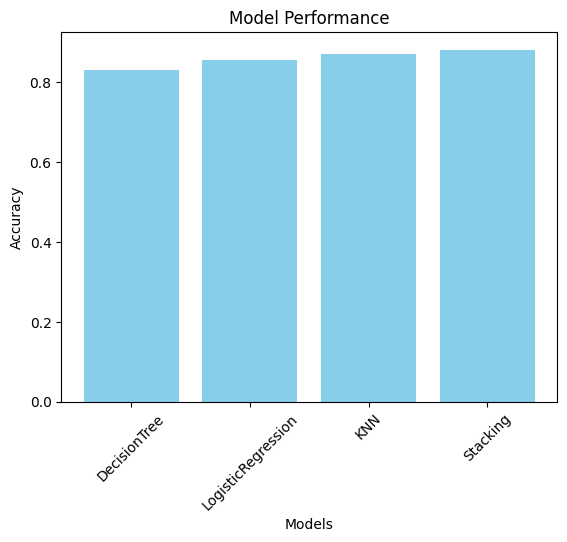

In [ ]:
# Visualize the models
models = ['DecisionTree', 'LogisticRegression', 'KNN', 'Stacking']
accuracies = [
    accuracy_score(test_y, tree1.fit(train_X, train_y).predict(test_X)),
    accuracy_score(test_y, lm.fit(train_X, train_y).predict(test_X)),
    accuracy_score(test_y, knn.fit(train_X, train_y).predict(test_X)),
    accuracy_score(test_y, y_pred_stack)
]

# Plot results
plt.bar(models, accuracies, color='skyblue')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Model Performance')
plt.xticks(rotation=45)
plt.show()